In [23]:
import pandas as pd
import warnings
pd.set_option("display.max_columns", None)
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error
from statsmodels.tsa.arima_process import ArmaProcess
from tqdm import tqdm
from itertools import product
from statsmodels.stats.diagnostic import acorr_ljungbox

from typing import Union


## Preprocessing

In this part, I will import the data from the csv file and do some preprocessing steps like transform data types, rename columns, visualize the data. 

You'll see that the whole dataset has data since 1972. However, in reality, not many datasets have such a long history. Therefore, to make it relevant to other projects, I will just use data since 2010.

In [8]:
df = pd.read_csv("canada international travelers.csv",  delimiter=",")

In [9]:
df

,Month,International travellers entering or returning to Canada,Non-resident visitors entering Canada,United States of America residents entering Canada,"United States of America residents, air","United States of America residents, land","United States of America residents, water",Residents of countries other than the United States of America entering Canada,"Residents of countries other than the United States of America, air","Residents of countries other than the United States of America, land","Residents of countries other than the United States of America, water",Canadian-resident visitors returning to Canada,Canadian residents returning from the United States of America,"Canadian residents returning from the United States of America, air","Canadian residents returning from the United States of America, land","Canadian residents returning from the United States of America, water",Canadian residents returning from countries other than the United States of America,"Canadian residents returning from countries other than the United States of America, air","Canadian residents returning from countries other than the United States of America, land","Canadian residents returning from countries other than the United States of America, water",Other travellers entering or returning to Canada,Crew entering or returning to Canada,"Crew, United States of America residents entering Canada","Crew, residents of countries other than the United States of America entering Canada","Crew, Canadian residents returning to Canada",Other non-tourism related purposes
0,January 1972,"3,424,506","1,379,519","1,360,612","43,711","1,316,823",78,"18,907","11,784","7,115",8,"1,870,342","1,776,119","92,684","1,683,285",150,"94,223","84,590","9,594",39,"174,645","174,645","67,362",0,"107,283",0
1,February 1972,"3,290,221","1,431,063","1,409,881","61,811","1,347,802",268,"21,182","17,110","3,464",608,"1,685,711","1,617,609","92,578","1,525,011",20,"68,102","66,277","1,430",395,"173,447","173,447","66,634",0,"106,813",0
2,March 1972,"4,120,948","1,739,676","1,708,559","79,182","1,629,081",296,"31,117","23,264","7,853",0,"2,208,453","2,097,841","133,464","1,964,358",19,"110,612","106,915","3,697",0,"172,819","172,819","71,317",0,"101,502",0
3,April 1972,"4,801,257","2,098,156","2,055,510","84,630","1,970,598",282,"42,646","28,999","13,636",11,"2,538,543","2,452,398","128,877","2,323,409",112,"86,145","84,802","1,339",4,"164,558","164,558","70,498",0,"94,060",0
4,May 1972,"5,849,057","2,987,394","2,906,659","98,872","2,785,818","21,969","80,735","50,028","29,530","1,177","2,680,776","2,600,898","90,018","2,507,339","3,541","79,878","76,720","1,201","1,957","180,887","180,887","77,315",0,"103,572",0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
649,February 2026,"5,408,197","1,478,633","1,140,552","279,030","857,723","3,799","338,081","307,905","29,711",465,"3,326,206","1,965,884","749,543","1,215,320","1,021","1,360,322","1,360,292",25,5,"603,358","538,464","63,832","41,693","432,939","64,894"
650,March 2026,"6,565,088","1,662,215","1,313,158","340,901","960,470","11,787","349,057","312,917","35,279",861,"4,214,270","2,584,339","934,145","1,645,703","4,491","1,629,931","1,629,825",66,40,"688,603","614,143","70,703","46,332","497,108","74,460"
651,April 2026,"6,356,894","1,886,926","1,454,250","366,572","1,046,931","40,747","432,676","380,351","48,702","3,623","3,776,851","2,393,095","805,904","1,578,592","8,599","1,383,756","1,383,010",71,675,"693,117","618,887","67,533","62,877","488,477","74,230"
652,May 2026,"7,425,581","2,891,190","2,225,875","510,005","1,441,984","273,886","665,315","533,856","77,121","54,338","3,702,374","2,550,542","703,732","1,803,242","43,568","1,151,832","1,147,911",83,"3,838","832,017","751,397","72,210","189,178","490,009","80,620"


In [10]:
df["Month"] = pd.to_datetime(df["Month"], format="%B %Y")

In [11]:
for col in df.columns:
    if col != "Month":
        df[col] = df[col].str.replace(',', '').astype(int)

In [12]:
df = df.rename(columns={
    "International travellers entering or returning to Canada": "Total",

    "Non-resident visitors entering Canada": "NonResident",

    "United States of America residents entering Canada": "US",
    "United States of America residents, air": "US_Air",
    "United States of America residents, land": "US_Land",
    "United States of America residents, water": "US_Water",

    "Residents of countries other than the United States of America entering Canada": "Overseas",
    "Residents of countries other than the United States of America, air": "Overseas_Air",
    "Residents of countries other than the United States of America, land": "Overseas_Land",
    "Residents of countries other than the United States of America, water": "Overseas_Water",

    "Canadian-resident visitors returning to Canada": "CanadianResident",

    "Canadian residents returning from the United States of America": "Canadian_US",
    "Canadian residents returning from the United States of America, air": "Canadian_US_Air",
    "Canadian residents returning from the United States of America, land": "Canadian_US_Land",
    "Canadian residents returning from the United States of America, water": "Canadian_US_Water",

    "Canadian residents returning from countries other than the United States of America": "Canadian_Overseas",
    "Canadian residents returning from countries other than the United States of America, air": "Canadian_Overseas_Air",
    "Canadian residents returning from countries other than the United States of America, land": "Canadian_Overseas_Land",
    "Canadian residents returning from countries other than the United States of America, water": "Canadian_Overseas_Water",

    "Other travellers entering or returning to Canada": "Other",

    "Crew entering or returning to Canada": "Crew",
    "Crew, United States of America residents entering Canada": "Crew_US",
    "Crew, residents of countries other than the United States of America entering Canada": "Crew_Overseas",
    "Crew, Canadian residents returning to Canada": "Crew_Canadian",

    "Other non-tourism related purposes": "Other_NonTourism"
})

In [13]:
df

,Month,Total,NonResident,US,US_Air,US_Land,US_Water,Overseas,Overseas_Air,Overseas_Land,Overseas_Water,CanadianResident,Canadian_US,Canadian_US_Air,Canadian_US_Land,Canadian_US_Water,Canadian_Overseas,Canadian_Overseas_Air,Canadian_Overseas_Land,Canadian_Overseas_Water,Other,Crew,Crew_US,Crew_Overseas,Crew_Canadian,Other_NonTourism
0,1972-01-01,3424506,1379519,1360612,43711,1316823,78,18907,11784,7115,8,1870342,1776119,92684,1683285,150,94223,84590,9594,39,174645,174645,67362,0,107283,0
1,1972-02-01,3290221,1431063,1409881,61811,1347802,268,21182,17110,3464,608,1685711,1617609,92578,1525011,20,68102,66277,1430,395,173447,173447,66634,0,106813,0
2,1972-03-01,4120948,1739676,1708559,79182,1629081,296,31117,23264,7853,0,2208453,2097841,133464,1964358,19,110612,106915,3697,0,172819,172819,71317,0,101502,0
3,1972-04-01,4801257,2098156,2055510,84630,1970598,282,42646,28999,13636,11,2538543,2452398,128877,2323409,112,86145,84802,1339,4,164558,164558,70498,0,94060,0
4,1972-05-01,5849057,2987394,2906659,98872,2785818,21969,80735,50028,29530,1177,2680776,2600898,90018,2507339,3541,79878,76720,1201,1957,180887,180887,77315,0,103572,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
649,2026-02-01,5408197,1478633,1140552,279030,857723,3799,338081,307905,29711,465,3326206,1965884,749543,1215320,1021,1360322,1360292,25,5,603358,538464,63832,41693,432939,64894
650,2026-03-01,6565088,1662215,1313158,340901,960470,11787,349057,312917,35279,861,4214270,2584339,934145,1645703,4491,1629931,1629825,66,40,688603,614143,70703,46332,497108,74460
651,2026-04-01,6356894,1886926,1454250,366572,1046931,40747,432676,380351,48702,3623,3776851,2393095,805904,1578592,8599,1383756,1383010,71,675,693117,618887,67533,62877,488477,74230
652,2026-05-01,7425581,2891190,2225875,510005,1441984,273886,665315,533856,77121,54338,3702374,2550542,703732,1803242,43568,1151832,1147911,83,3838,832017,751397,72210,189178,490009,80620


In [14]:
df.dtypes

Month                      datetime64[ns]
Total                               int64
NonResident                         int64
US                                  int64
US_Air                              int64
US_Land                             int64
US_Water                            int64
Overseas                            int64
Overseas_Air                        int64
Overseas_Land                       int64
Overseas_Water                      int64
CanadianResident                    int64
Canadian_US                         int64
Canadian_US_Air                     int64
Canadian_US_Land                    int64
Canadian_US_Water                   int64
Canadian_Overseas                   int64
Canadian_Overseas_Air               int64
Canadian_Overseas_Land              int64
Canadian_Overseas_Water             int64
Other                               int64
Crew                                int64
Crew_US                             int64
Crew_Overseas                     

In [15]:
df = df[df['Month'] >= '01-01-2010']

Text(0.5, 1.0, "The total number of Canada's International Travelers over the period from 2010 to 2026 (Unit: 10M)")

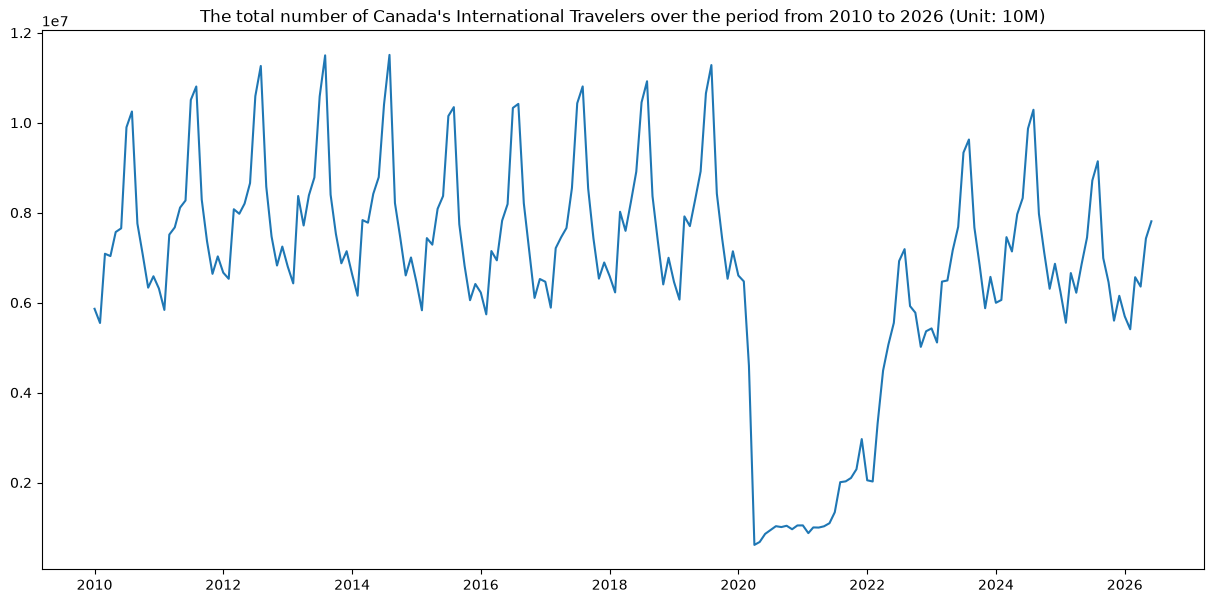

In [16]:
plt.figure(figsize=(15,7))

plt.plot(df[['Month']],df[['Total']])

plt.title("The total number of Canada's International Travelers over the period from 2010 to 2026 (Unit: 10M)")

### Test the stationarity

- Why do we need to test the stationarity? "A stationary time series is the series that has a constant mean, variance, and autocorrelation. These properties **do not change over time**. MA, AR, ARMA models assume stationarity.
- How to test? I use **Augmented Dickey-Fuller (ADF)** test. ADF runs an autoregressive model to check how strongly past value predict future values. If p-value is low, we can reject the Null hypothesis and conclude the data is stationary.
​


In [17]:
from statsmodels.tsa.stattools import adfuller
 
ADF_result = adfuller(df['Total'])  

print(f'ADF Statistic: {ADF_result[0]}')     
print(f'p-value: {ADF_result[1]}') 

ADF Statistic: -3.2360562984238794
p-value: 0.017990191141548838


p-value = 0.017... < 0.05, so we can reject the Null hypothesis. The series is stationary.

### Autocorrelation
- What is it? Autocorrelation measures the linear relationship between lagged values of a time series. For example, with lag = 1: we have the correlation between the current value and it's value in time t-1
- What if the series has no autocorrelations? It means past values cannot predict future values using simple linear models. In another word, it is a random walk. Our statistical models cannot be used.

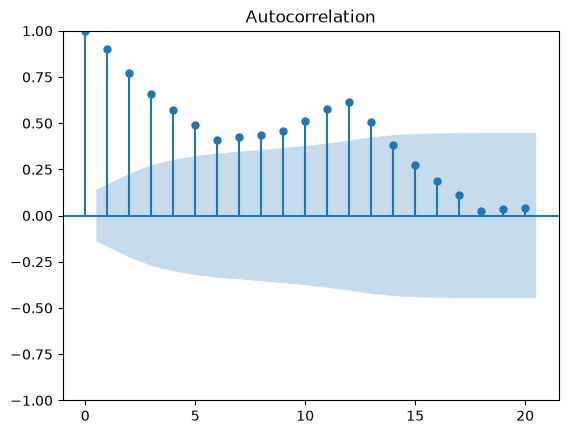

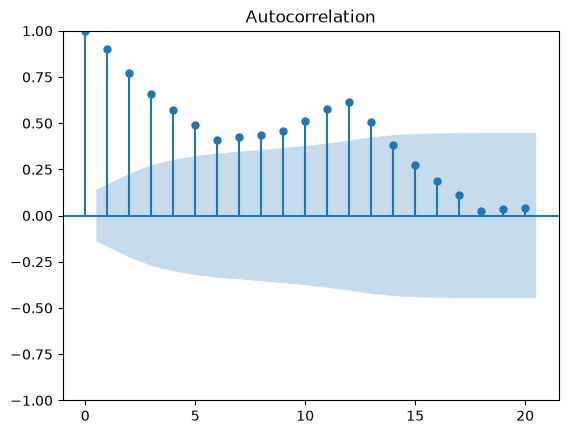

In [18]:
from statsmodels.graphics.tsaplots import plot_acf
 
plot_acf(df['Total'], lags=20)

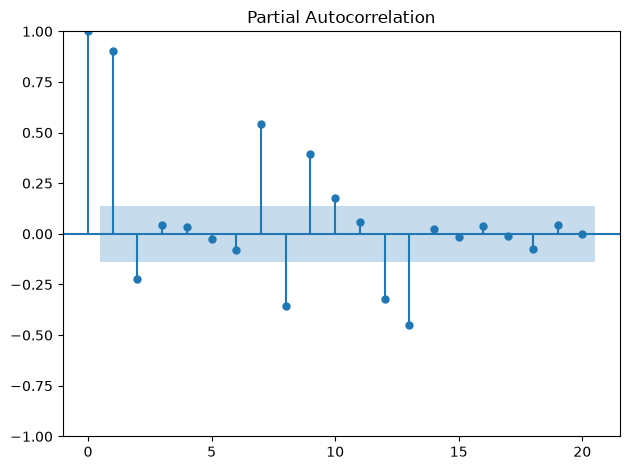

In [19]:
from statsmodels.graphics.tsaplots import plot_pacf
 
plot_pacf(df['Total'], lags=20);   
 
plt.tight_layout()

These charts show that the data follow a AR process, with a strong seasonal pattern

# Baseline Models

In this part, I evaluated several classical statistical time-series forecasting methods and simple naive models. The goal is to use them as the baseline to further develop the statistical models.

**Statistical models:**

* **MA (Moving Average):** Uses past forecast errors to model the current value of the time series.
* **AR (Autoregressive):** Uses previous observations of the time series to predict future values.
* **ARMA (Autoregressive Moving Average):** Combines AR and MA components to model both relationships with past observations and past forecast errors.

To provide meaningful benchmarks, I also evaluated three simple forecasting approaches:

* **Mean:** Predicts future values using the historical average.
* **Seasonal Naive:** Predicts future values using last year's value. Ex: to predict data for Jan 2026, use the data of Jan 2025.



In [20]:
#Predict 6 months in 2026

df_train = df[['Total']].iloc[:len(df)-6]
df_test = df[['Total']].iloc[len(df)-6:]

In [32]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

def rolling_forecast(df, train_len, test_len, window, method) -> list:
    total_len = train_len + test_len

    if method == "mean":
        pred_mean = []
        for i in range(train_len, total_len, window):
            mean = np.mean(df[:i].values)
            pred_mean.extend(mean for _ in range(window))
        return pred_mean
    
    # elif method == "last":
    #     pred_last = []
    #     for i in range(train_len, total_len, window):
    #         last = df[:i].iloc[-1].values[0]
    #         pred_last.extend(last for _ in range(window))
    #     return pred_last 

    elif method == "snaive":

        pred_snaive = []

        for i in range(train_len, total_len, window):
            seasonal_values = df[:i].iloc[-12:].values.flatten()

            predictions = np.tile(seasonal_values, 
                                  int(np.ceil(window / 12)))[:window]

            pred_snaive.extend(predictions)

        return pred_snaive     

    elif method == "MA":
        pred_MA = []
        
        for i in range(train_len, total_len, window):
            model = SARIMAX(df[:i], order=(0,0,13))                 
            res = model.fit(disp=False)
            predictions = res.get_prediction(0, i + window - 1)
            oos_pred = predictions.predicted_mean.iloc[-window:]    
            pred_MA.extend(oos_pred)
            
        return pred_MA 

    elif method == 'AR':
        pred_AR = []
        
        for i in range(train_len, total_len, window):
            model = SARIMAX(df[:i], order=(1,0,0))      
            res = model.fit(disp=False)
            predictions = res.get_prediction(0, i + window - 1)
            oos_pred = predictions.predicted_mean.iloc[-window:]
            pred_AR.extend(oos_pred)

        return pred_AR 

    elif method == 'ARMA':
        pred_ARMA = []
        
        for i in range(train_len, total_len, window):
            model = SARIMAX(df[:i], order=(1,0,13))      
            res = model.fit(disp=False)
            predictions = res.get_prediction(0, i + window - 1)
            oos_pred = predictions.predicted_mean.iloc[-window:]
            pred_ARMA.extend(oos_pred)            
            
        return pred_ARMA          


In [33]:
pred_df = df_test.copy()
df_model = df[['Total']].copy()
 
TRAIN_LEN = len(df_train)
TEST_LEN = len(df_test)
WINDOW = 1
 
pred_mean = rolling_forecast(df_model, TRAIN_LEN, TEST_LEN, WINDOW, 'mean')
pred_snaive = rolling_forecast(df_model, TRAIN_LEN, TEST_LEN, WINDOW, 'snaive')
pred_MA = rolling_forecast(df_model, TRAIN_LEN, TEST_LEN, WINDOW, 'MA')
pred_AR = rolling_forecast(df_model, TRAIN_LEN, TEST_LEN, WINDOW, 'AR')
pred_ARMA = rolling_forecast(df_model, TRAIN_LEN, TEST_LEN, WINDOW, 'ARMA')
 
pred_df['pred_mean'] = pred_mean
pred_df['pred_snaive'] = pred_snaive
pred_df['pred_MA'] = pred_MA
pred_df['pred_AR'] = pred_AR
pred_df['pred_ARMA'] = pred_ARMA
 
pred_df

,Total,pred_mean,pred_snaive,pred_MA,pred_AR,pred_ARMA
648,5694588,6.801670e+06,6241804,5.477332e+06,6.073756e+06,5.817120e+06
649,5408197,6.795934e+06,5552560,4.674215e+06,5.621470e+06,5.245941e+06
650,6565088,6.788780e+06,6657640,5.180214e+06,5.338378e+06,5.838961e+06
651,6356894,6.787633e+06,6220312,6.062714e+06,6.483413e+06,6.325325e+06
652,7425581,6.785436e+06,6850266,6.002861e+06,6.277550e+06,6.805332e+06
653,7808169,6.788685e+06,7448847,7.293725e+06,7.336679e+06,7.445496e+06


## Evaluations

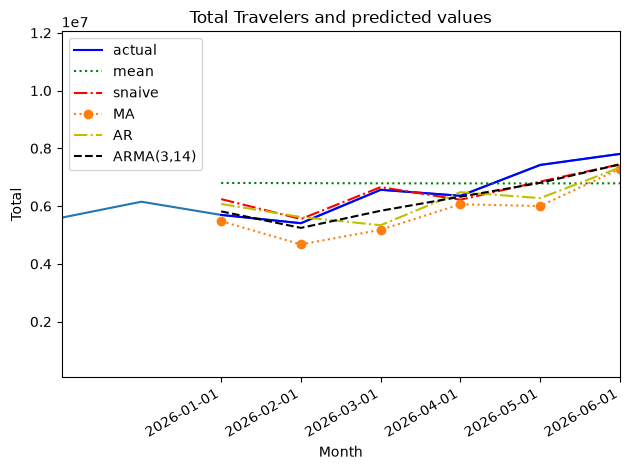

In [34]:
fig, ax = plt.subplots()
 
ax.plot(df['Total'])
ax.plot(pred_df['Total'], 'b-', label='actual')
ax.plot(pred_df['pred_mean'], 'g:', label='mean')
ax.plot(pred_df['pred_snaive'], 'r-.', label='snaive')
ax.plot(pred_df['pred_MA'], 'o:', label='MA')
ax.plot(pred_df['pred_AR'], 'y-.', label='AR')
ax.plot(pred_df['pred_ARMA'], 'k--', label='ARMA(3,14)')
ax.legend(loc=2)
ax.set_xlabel('Month')
ax.set_ylabel('Total')
 
# ax.axvspan(6, 650, color='#808080', alpha=0.2)     
 
ax.set_xlim(646, 653)                                
 
plt.xticks(
    [648, 649, 650, 651, 652, 653],
    ['2026-01-01', '2026-02-01', '2026-03-01', '2026-04-01', '2026-05-01', "2026-06-01"])
 
fig.autofmt_xdate()

plt.title("Total Travelers and predicted values")
plt.tight_layout()

For evaluations, we use 3 main metrics:
- MAPE (Mean Absolute Percentage Error): Measures forecast error in percentage terms. Useful when comparing accuracy across periods with different demand levels.
- MAE (Mean Absolute Error): Measures the typical size of the forecast error in the original units. Useful for understanding the expected business impact of forecast errors.
- MSE (Mean Squared Error): Penalizes large errors more heavily. Useful when significant forecasting mistakes are particularly costly to the business.

In [35]:
def mape(y_true, y_pred):
    return np.mean(np.abs((y_true-y_pred)/y_true))*100

In [36]:

df_eval = pd.DataFrame(columns=["Method","MAPE","MSE","MAE"])

methods = ["mean","snaive","MA","AR","ARMA"]

for m in methods:

    pred_col = "pred_"+m

    df_eval.loc[len(df_eval)] = [
    m,
    mape(pred_df['Total'], pred_df['pred_'+m]),
    mean_squared_error(pred_df['Total'], pred_df['pred_'+m]),
    mean_absolute_error(pred_df['Total'], pred_df['pred_'+m])
    ]

df_eval

,Method,MAPE,MSE,MAE
0,mean,12.826919,8.060253e+11,801479.948642
1,snaive,4.697781,1.346010e+11,309225.000000
2,MA,11.476217,8.131889e+11,761242.794386
3,AR,8.796072,5.417258e+11,594198.520890
4,ARMA,4.951101,1.809731e+11,337567.591156



Among the evaluated models, we found Seasonal-Naive (4.7% MAPE) outperformed MA, AR, and ARMA models, demonstrating strong annual seasonal patterns in traveler demand.

Also, ARMA achieved the stronger forecasting performance than MA and AR, with a MAPE of 4.8%. This suggest that combining the AR and MA components performed better than either component alone.

Let's try improving ARMA model.

# Updated ARMA Model

## Model Selection using AIC and Residual Analysis

We used AIC and residual analysis to assess whether the models were appropriate.

- AIC (Akaike Information Criterion): Balances model fit with model complexity. A lower AIC indicates a better trade-off between the two.
- Residual Analysis: Examines the errors left unexplained by the model. A good model should have residuals that resemble white noise, with no clear patterns or significant autocorrelation remaining.

In [37]:
def optimize_ARMA(endog: Union[pd.Series, list], order_list: list) -> pd.DataFrame:
    
    results = []
    
    for order in tqdm(order_list):
        try: 
            model = SARIMAX(endog, order=(order[0], 0, order[1]), simple_differencing=False).fit(disp=False)
        except:
            continue
            
        aic = model.aic
        results.append([order, aic])
        
    result_df = pd.DataFrame(results)
    result_df.columns = ['(p,q)', 'AIC']
    
    #Sort in ascending order, lower AIC is better
    result_df = result_df.sort_values(by='AIC', ascending=True).reset_index(drop=True)
    
    return result_df

In [ ]:
ps = range(0, 20, 1)                   
qs = range(0, 20, 1)                   
 
order_list = list(product(ps, qs))

In [ ]:
result_df = optimize_ARMA(df_train['Total'], order_list)
result_df.head(10)

100%|██████████| 400/400 [04:04<00:00,  1.64it/s]


,"(p,q)",AIC
0,"(9, 9)",5676.462500
1,"(14, 0)",5678.213266
2,"(10, 10)",5678.491512
3,"(19, 0)",5678.603401
4,"(11, 9)",5678.624111
5,"(9, 10)",5678.640264
6,"(10, 9)",5679.058799
7,"(13, 0)",5679.126229
8,"(15, 0)",5679.462461
9,"(16, 0)",5680.247173


Looks like p = 9 and q = 9 is the best configurations. Now let's check the residual analysis.

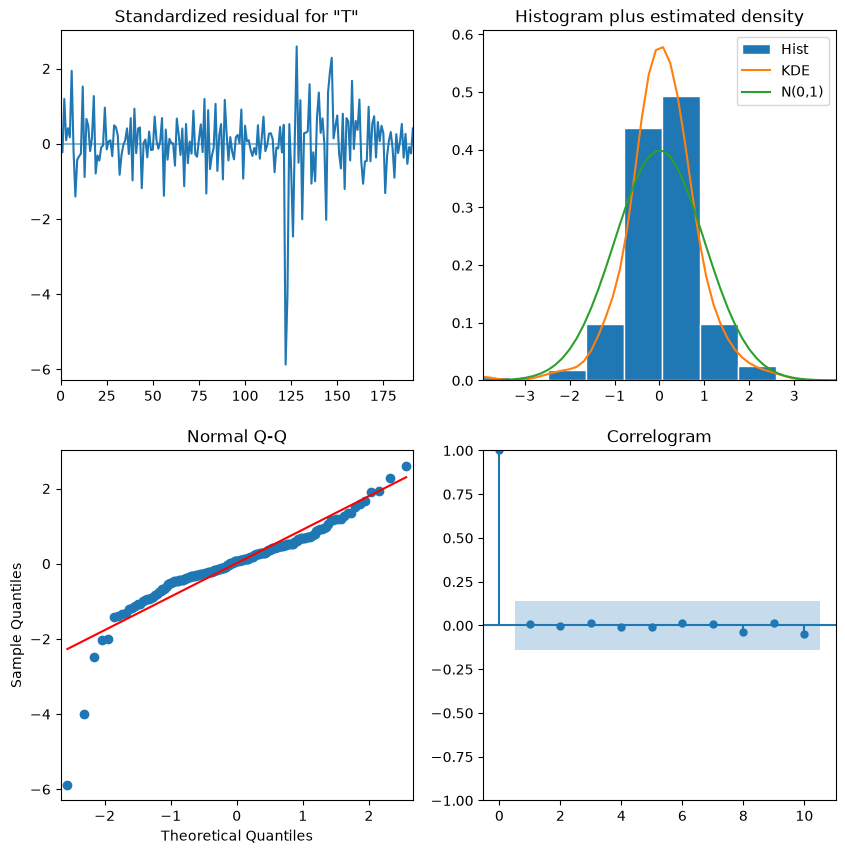

In [ ]:
model = SARIMAX(df_train['Total'], order=(9,0,9), simple_differencing=False)
model_fit = model.fit(disp=False)

model_fit.plot_diagnostics(figsize=(10, 10));


Residual analysis helps assess whether the model has captured the underlying patterns in the data.

The **Normal Q-Q plot** shows that the residuals approximately follow a normal distribution, with a few outliers in the left tail. The **histogram and standardized residual plot** show a similar pattern.

Overall, the residuals appear to be approximately normally distributed with no obvious systematic patterns.

Let's conduct a Ljung-Box test. The Ljung-Box test is a statistical test that determines whether the autocorrelation of a group of data is significantly different from 0. We use the Ljung-Box test to determine whether the residuals contain significant autocorrelation.

This helps verify whether the residuals are truly uncorrelated (white noise) after fitting the model.

In [ ]:
residuals = model_fit.resid
 
acorr_ljungbox(residuals, np.arange(1, 20, 1))


,lb_stat,lb_pvalue
1,0.041945,0.837724
2,1.470039,0.479496
3,1.496139,0.683162
4,1.801561,0.772197
5,1.805733,0.875319
6,6.600482,0.359378
7,6.638936,0.467416
8,8.000756,0.433396
9,8.016950,0.532439
10,8.279964,0.601511


We got large p-value (>> 0.05) across 20 lags, so we fail to reject the null hypothesis of no autocorrelation.

This suggests that there is no statistically significant autocorrelation remaining in the residuals. In other words, the residuals behave approximately like random white noise, indicating that the model has captured the systematic temporal patterns in the data.



### Update the model

In [44]:
def rolling_forecast(df, train_len, test_len, window, method) -> list:
    total_len = train_len + test_len

    if method == "mean":
        pred_mean = []
        for i in range(train_len, total_len, window):
            mean = np.mean(df[:i].values)
            pred_mean.extend(mean for _ in range(window))
        return pred_mean

    elif method == "snaive":

        pred_snaive = []

        for i in range(train_len, total_len, window):
            seasonal_values = df[:i].iloc[-12:].values.flatten()

            predictions = np.tile(seasonal_values, 
                                  int(np.ceil(window / 12)))[:window]

            pred_snaive.extend(predictions)

        return pred_snaive 
    
    elif method == "MA":
        pred_MA = []
        
        for i in range(train_len, total_len, window):
            model = SARIMAX(df[:i], order=(0,0,13))                  
            res = model.fit(disp=False)
            predictions = res.get_prediction(0, i + window - 1)
            oos_pred = predictions.predicted_mean.iloc[-window:]    #Out of sample pred
            pred_MA.extend(oos_pred)
            
        return pred_MA 

    elif method == 'AR':
        pred_AR = []
        
        for i in range(train_len, total_len, window):
            model = SARIMAX(df[:i], order=(1,0,0))      
            res = model.fit(disp=False)
            predictions = res.get_prediction(0, i + window - 1)
            oos_pred = predictions.predicted_mean.iloc[-window:]
            pred_AR.extend(oos_pred)
            
        return pred_AR     


    elif method == 'ARMA':
        pred_ARMA = []
        
        for i in range(train_len, total_len, window):
            model = SARIMAX(df[:i], order=(9,0,9))      
            res = model.fit(disp=False)
            predictions = res.get_prediction(0, i + window - 1)
            oos_pred = predictions.predicted_mean.iloc[-window:]
            pred_ARMA.extend(oos_pred)
            
        return pred_ARMA          


In [45]:
pred_df = df_test.copy()
df_model = df[['Total']].copy()
 
TRAIN_LEN = len(df_train)
TEST_LEN = len(df_test)
WINDOW = 1
 
pred_mean = rolling_forecast(df_model, TRAIN_LEN, TEST_LEN, WINDOW, 'mean')
pred_snaive = rolling_forecast(df_model, TRAIN_LEN, TEST_LEN, WINDOW, 'snaive')
pred_MA = rolling_forecast(df_model, TRAIN_LEN, TEST_LEN, WINDOW, 'MA')
pred_AR = rolling_forecast(df_model, TRAIN_LEN, TEST_LEN, WINDOW, 'AR')
pred_ARMA = rolling_forecast(df_model, TRAIN_LEN, TEST_LEN, WINDOW, 'ARMA')
 
pred_df['pred_mean'] = pred_mean
pred_df['pred_snaive'] = pred_snaive
pred_df['pred_MA'] = pred_MA
pred_df['pred_AR'] = pred_AR
pred_df['pred_ARMA'] = pred_ARMA
 
pred_df

,Total,pred_mean,pred_snaive,pred_MA,pred_AR,pred_ARMA
648,5694588,6.801670e+06,6241804,5.477332e+06,6.073756e+06,5.686681e+06
649,5408197,6.795934e+06,5552560,4.674215e+06,5.621470e+06,5.298207e+06
650,6565088,6.788780e+06,6657640,5.180214e+06,5.338378e+06,6.633013e+06
651,6356894,6.787633e+06,6220312,6.062714e+06,6.483413e+06,6.141186e+06
652,7425581,6.785436e+06,6850266,6.002861e+06,6.277550e+06,7.118752e+06
653,7808169,6.788685e+06,7448847,7.293725e+06,7.336679e+06,7.853494e+06


### Evaluations

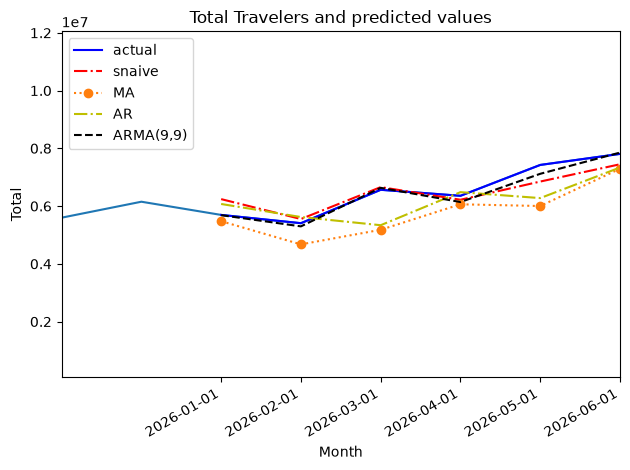

In [46]:
fig, ax = plt.subplots()
 
ax.plot(df['Total'])
ax.plot(pred_df['Total'], 'b-', label='actual')
# ax.plot(pred_df['pred_mean'], 'g:', label='mean')
ax.plot(pred_df['pred_snaive'], 'r-.', label='snaive')
ax.plot(pred_df['pred_MA'], 'o:', label='MA')
ax.plot(pred_df['pred_AR'], 'y-.', label='AR')
ax.plot(pred_df['pred_ARMA'], 'k--', label='ARMA(9,9)')
ax.legend(loc=2)
ax.set_xlabel('Month')
ax.set_ylabel('Total')
 
# ax.axvspan(6, 650, color='#808080', alpha=0.2)     
 
ax.set_xlim(646, 653)                                
 
plt.xticks(
    [648, 649, 650, 651, 652, 653],
    ['2026-01-01', '2026-02-01', '2026-03-01', '2026-04-01', '2026-05-01', "2026-06-01"])
 
fig.autofmt_xdate()

plt.title("Total Travelers and predicted values")
plt.tight_layout()

In [47]:

df_eval = pd.DataFrame(columns=["Method","MAPE","MSE","MAE"])

methods = ["mean","snaive","MA","AR","ARMA"]

for m in methods:

    pred_col = "pred_"+m

    df_eval.loc[len(df_eval)] = [
    m,
    mape(pred_df['Total'], pred_df['pred_'+m]),
    mean_squared_error(pred_df['Total'], pred_df['pred_'+m]),
    mean_absolute_error(pred_df['Total'], pred_df['pred_'+m])
    ]

df_eval

,Method,MAPE,MSE,MAE
0,mean,12.826919,8.060253e+11,801479.948642
1,snaive,4.697781,1.346010e+11,309225.000000
2,MA,11.476217,8.131889e+11,761242.794386
3,AR,8.796072,5.417258e+11,594198.520890
4,ARMA,1.885516,2.658377e+10,125614.108380


Here, after selecting the parameters, we could improve the ARMA model by reducing MAPE from 4.8 to 1.88%

## Add seasonal cycles

The dataset has a strong seasonal pattern. It looks like the trend repeats every 12 months. 

Let's look at the decomposition. Decomposition STL is a powerful tool that breaks down your time series data into three components: trend, seasonality, and noise (remainder).

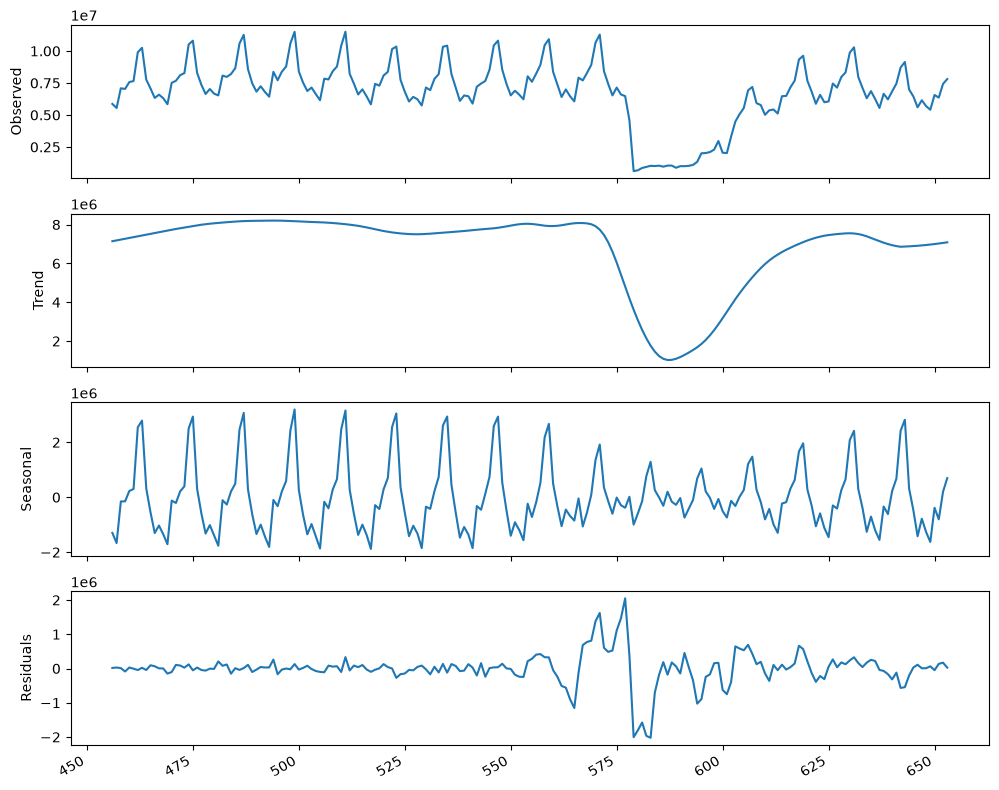

In [ ]:
from statsmodels.tsa.seasonal import STL
 
decomposition = STL(df['Total'], period=12).fit()      
 
fig, (ax1, ax2, ax3, ax4) = plt.subplots(nrows=4, ncols=1, sharex=True, figsize=(10,8))                                          
 
ax1.plot(decomposition.observed)
ax1.set_ylabel('Observed')
 
ax2.plot(decomposition.trend)
ax2.set_ylabel('Trend')
 
ax3.plot(decomposition.seasonal)
ax3.set_ylabel('Seasonal')
 
ax4.plot(decomposition.resid)
ax4.set_ylabel('Residuals')
 
# plt.xticks(np.arange(0, 145, 12), np.arange(1949, 1962, 1))
 
fig.autofmt_xdate()
plt.tight_layout()

The STL decomposition shows that the seasonal pattern changes substantially around the onset of COVID-19. However, toward the end of the period, the seasonal component appears to gradually return to a pattern closer to what we observed before COVID-19.

About SARIMA:

SARIMA stands for Seasonal AutoRegressive Integrated Moving Average. It is a time-series forecasting model designed for data that has trend/non-stationarity and repeating seasonal patterns.

There are two parts:

- Non-seasonal part: (p,d,q) similar to ARIMA
- Seasonal part: (P,D,Q)s - the seasonal part
	​


In [23]:
def optimize_SARIMA(endog: Union[pd.Series, list], order_list: list, d: int, D: int, s: int) -> pd.DataFrame:      
    
    results = []
    
    for order in tqdm(order_list):   
        try:
            model = SARIMAX(
                endog, 
                order=(order[0], d, order[1]),
                seasonal_order=(order[2], D, order[3], s),
                simple_differencing=False).fit(disp=False)
        except:
            continue
        
        aic = model.aic
        results.append([order, aic])
    
    result_df = pd.DataFrame(results)
    result_df.columns = ['(p,q,P,Q)', 'AIC']
    
    #Sort in ascending order, lower AIC is better
    
    result_df = result_df.sort_values(by='AIC', ascending=True).reset_index(drop=True)
    
    return result_df

### Model Selection

Again, we use AIC and residual analysis to select the best model

In [ ]:
ps = range(0, 20, 1)                                                     
qs = range(0, 20, 1)
Ps = range(0, 4, 1)
Qs = range(0, 4, 1)
 
SARIMA_order_list = list(product(ps, qs, Ps, Qs))                                                              
 
d = 0
D = 0
s = 6 #Choose s=6 due to the autocorrrelation analysis
 
SARIMA_result_df = optimize_SARIMA(df_train, SARIMA_order_list, d, D, s)      

 80%|████████  | 5139/6400 [10:26<02:43,  7.69it/s]  

(14, 0, 0, 2) with s=6 is the best parameters overall.

In [40]:
SARIMA_result_df.head(20)


,"(p,q,P,Q)",AIC
0,"(14, 0, 0, 2)",5670.612353
1,"(15, 0, 0, 2)",5672.708996
2,"(13, 5, 0, 2)",5673.607407
3,"(16, 0, 0, 2)",5673.623419
4,"(13, 5, 0, 3)",5674.560571
5,"(11, 5, 0, 2)",5674.865473
6,"(17, 0, 0, 2)",5675.626422
7,"(15, 1, 0, 2)",5675.920987
8,"(13, 4, 0, 2)",5676.053018
9,"(13, 5, 0, 1)",5676.175249


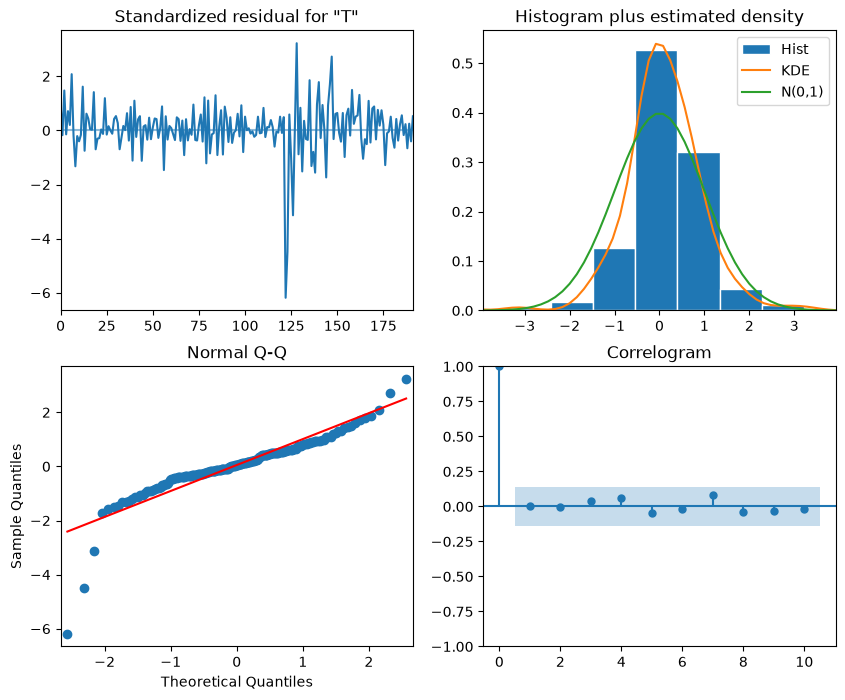

In [52]:
SARIMA_model = SARIMAX(df_train, order=(14,0,0), seasonal_order=(0,0,2,6), simple_differencing=False)
SARIMA_model_fit = SARIMA_model.fit(disp=False)
 
SARIMA_model_fit.plot_diagnostics(figsize=(10,8));

In [53]:
from statsmodels.stats.diagnostic import acorr_ljungbox
 
residuals = SARIMA_model_fit.resid
 
acorr_ljungbox(residuals, np.arange(1, 11, 1))

,lb_stat,lb_pvalue
1,0.053535,0.817022
2,2.018164,0.364554
3,2.024958,0.567243
4,3.694011,0.448998
5,3.802547,0.578180
6,6.963975,0.324192
7,7.116396,0.416862
8,8.356619,0.399432
9,8.543450,0.480438
10,8.595119,0.570910


Similar to the previous section, this model also passed the acorr_ljungbox test, indicating that the residuals are approximately uncorrelated and that the model captures the main patterns in the time series.

### Evaluations

In [48]:
def rolling_forecast(df, train_len, test_len, window, method) -> list:
    total_len = train_len + test_len

    if method == "mean":
        pred_mean = []
        for i in range(train_len, total_len, window):
            mean = np.mean(df[:i].values)
            pred_mean.extend(mean for _ in range(window))
        return pred_mean
    
    elif method == "snaive":

        pred_snaive = []

        for i in range(train_len, total_len, window):
            seasonal_values = df[:i].iloc[-12:].values.flatten()

            predictions = np.tile(seasonal_values, 
                                  int(np.ceil(window / 12)))[:window]

            pred_snaive.extend(predictions)

        return pred_snaive   
    
    elif method == "MA":
        pred_MA = []
        
        for i in range(train_len, total_len, window):
            model = SARIMAX(df[:i], order=(0,0,13))               
            res = model.fit(disp=False)
            predictions = res.get_prediction(0, i + window - 1)
            oos_pred = predictions.predicted_mean.iloc[-window:]    #Out of sample pred
            pred_MA.extend(oos_pred)
            
        return pred_MA 

    elif method == 'AR':
        pred_AR = []
        
        for i in range(train_len, total_len, window):
            model = SARIMAX(df[:i], order=(1,0,0))      
            res = model.fit(disp=False)
            predictions = res.get_prediction(0, i + window - 1)
            oos_pred = predictions.predicted_mean.iloc[-window:]
            pred_AR.extend(oos_pred)
            
        return pred_AR     


    elif method == 'ARMA':
        pred_ARMA = []
        
        for i in range(train_len, total_len, window):
            model = SARIMAX(df[:i], order=(9,0,9))      
            res = model.fit(disp=False)
            predictions = res.get_prediction(0, i + window - 1)
            oos_pred = predictions.predicted_mean.iloc[-window:]
            pred_ARMA.extend(oos_pred)
            
        return pred_ARMA   
           

    elif method == 'SARIMA':
        pred_SARIMA = []
        
        for i in range(train_len, total_len, window):
            model = SARIMAX(df[:i], order=(14,0,0), seasonal_order=(0,0,2,6), simple_differencing=False)      
            res = model.fit(disp=False)
            predictions = res.get_prediction(0, i + window - 1)
            oos_pred = predictions.predicted_mean.iloc[-window:]
            pred_SARIMA.extend(oos_pred)
            
        return pred_SARIMA   

In [49]:
pred_df = df_test.copy()
df_model = df[['Total']].copy()
 
TRAIN_LEN = len(df_train)
TEST_LEN = len(df_test)
WINDOW = 1
 
pred_mean = rolling_forecast(df_model, TRAIN_LEN, TEST_LEN, WINDOW, 'mean')
pred_snaive = rolling_forecast(df_model, TRAIN_LEN, TEST_LEN, WINDOW, 'snaive')
pred_MA = rolling_forecast(df_model, TRAIN_LEN, TEST_LEN, WINDOW, 'MA')
pred_AR = rolling_forecast(df_model, TRAIN_LEN, TEST_LEN, WINDOW, 'AR')
pred_ARMA = rolling_forecast(df_model, TRAIN_LEN, TEST_LEN, WINDOW, 'ARMA')
pred_SARIMA = rolling_forecast(df_model, TRAIN_LEN, TEST_LEN, WINDOW, 'SARIMA')
 
pred_df['pred_mean'] = pred_mean
pred_df['pred_snaive'] = pred_snaive
pred_df['pred_MA'] = pred_MA
pred_df['pred_AR'] = pred_AR
pred_df['pred_ARMA'] = pred_ARMA
pred_df['pred_SARIMA'] = pred_SARIMA
 
pred_df

,Total,pred_mean,pred_snaive,pred_MA,pred_AR,pred_ARMA,pred_SARIMA
648,5694588,6.801670e+06,6241804,5.477332e+06,6.073756e+06,5.686681e+06,5.716196e+06
649,5408197,6.795934e+06,5552560,4.674215e+06,5.621470e+06,5.298207e+06,5.275431e+06
650,6565088,6.788780e+06,6657640,5.180214e+06,5.338378e+06,6.633013e+06,6.531908e+06
651,6356894,6.787633e+06,6220312,6.062714e+06,6.483413e+06,6.141186e+06,6.215001e+06
652,7425581,6.785436e+06,6850266,6.002861e+06,6.277550e+06,7.118752e+06,7.047865e+06
653,7808169,6.788685e+06,7448847,7.293725e+06,7.336679e+06,7.853494e+06,7.853984e+06


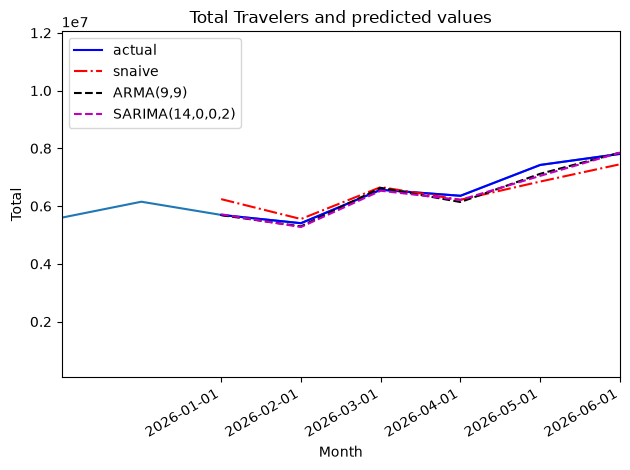

In [55]:
fig, ax = plt.subplots()
 
ax.plot(df['Total'])
ax.plot(pred_df['Total'], 'b-', label='actual')
# ax.plot(pred_df['pred_mean'], 'g:', label='mean')
ax.plot(pred_df['pred_snaive'], 'r-.', label='snaive')
# ax.plot(pred_df['pred_MA'], 'o:', label='MA')
# ax.plot(pred_df['pred_AR'], 'y-.', label='AR')
ax.plot(pred_df['pred_ARMA'], 'k--', label='ARMA(9,9)')
ax.plot(pred_df['pred_SARIMA'], 'm--', label='SARIMA(14,0,0,2)')
ax.legend(loc=2)
ax.set_xlabel('Month')
ax.set_ylabel('Total')
 
# ax.axvspan(6, 650, color='#808080', alpha=0.2)     
 
ax.set_xlim(646, 653)                                
 
plt.xticks(
    [648, 649, 650, 651, 652, 653],
    ['2026-01-01', '2026-02-01', '2026-03-01', '2026-04-01', '2026-05-01', "2026-06-01"])
 
fig.autofmt_xdate()

plt.title("Total Travelers and predicted values")
plt.tight_layout()

In [51]:

df_eval = pd.DataFrame(columns=["Method","MAPE","MSE","MAE"])

methods = ["mean","snaive","MA","AR","ARMA", "SARIMA"]

for m in methods:

    pred_col = "pred_"+m

    df_eval.loc[len(df_eval)] = [
    m,
    mape(pred_df['Total'], pred_df['pred_'+m]),
    mean_squared_error(pred_df['Total'], pred_df['pred_'+m]),
    mean_absolute_error(pred_df['Total'], pred_df['pred_'+m])
    ]

df_eval

,Method,MAPE,MSE,MAE
0,mean,12.826919,8.060253e+11,801479.948642
1,snaive,4.697781,1.346010e+11,309225.000000
2,MA,11.476217,8.131889e+11,761242.794386
3,AR,8.796072,5.417258e+11,594198.520890
4,ARMA,1.885516,2.658377e+10,125614.108380
5,SARIMA,1.874217,3.068273e+10,125496.290254


Despite adding the seasonal component, the SARIMA model didn't improve too much compared to our ARMA model. This could be because the seasonal pattern wasn't maintained. This observation is important because standard SARIMA assumes a relatively consistent seasonal structure. If COVID temporarily disrupted the seasonal pattern, SARIMA may not fully capture that structural change.

# Prophet

One thing we could have noticed so far, is the change in trend and seasonality due to the Covid disruption.

Let's expplore another method: Prophet.

Prophet is a time-series forecasting model developed by Meta that decomposes a time series into trend, seasonality, and holiday/event effects. It is designed to handle real-world time series with changing trends, strong seasonal patterns, missing data, and unusual events.

In [56]:
df_pp = df[["Month","Total"]]

In [57]:
df_pp.rename(columns = {"Month":"ds","Total":"y"},inplace=True)

## Treating COVID as one-off holiday

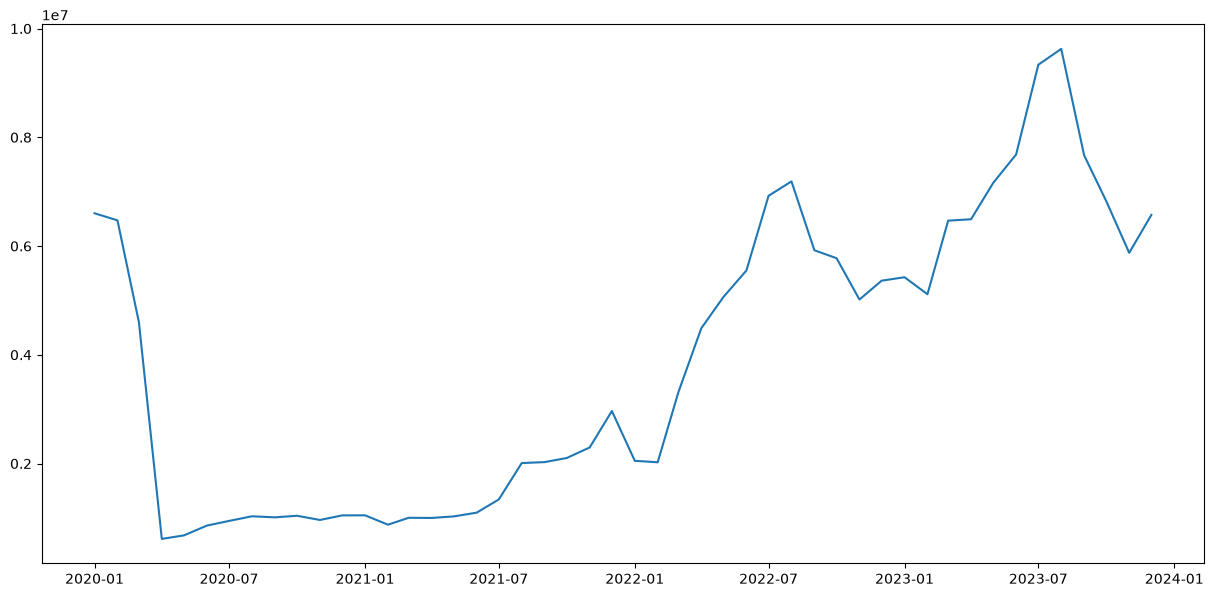

In [58]:
plt.figure(figsize=(15,7))

plt.plot(df_pp[(df_pp['ds'] >= '2020-01-01') & (df_pp['ds'] <= '2023-12-01')]['ds'],df_pp[(df_pp['ds'] >= '2020-01-01') & (df_pp['ds'] <= '2023-12-01')]['y'])

Based on information about covid in Canada and this chart, I'll set the Covid period from Jan 2020 to May 2022

In [59]:
lockdowns = df_pp[(df_pp['ds'] >= '2020-01-01') & (df_pp['ds'] <= '2022-05-01')][['ds']]

lockdowns['holiday'] = 'covid'

## Hyper Parameter tuning

In [61]:
from prophet import Prophet
from prophet.diagnostics import performance_metrics
from prophet.diagnostics import cross_validation

from itertools import product

In [62]:
#Predict 6 months in 2026

df_pp_train = df_pp.iloc[:len(df)-6]
df_pp_test = df_pp.iloc[len(df)-6:]

In [63]:

param_grid = {
    'changepoint_prior_scale': [0.001, 0.01, 0.1, 0.5],
    'seasonality_prior_scale': [0.01, 0.1, 1.0, 10.0],
}


product(*param_grid.values())
 
all_params = [dict(zip(param_grid.keys(), v)) for v in product(*param_grid.values())]
 
maes = []
 
for params in all_params:                                    
    m = Prophet(**params,holidays=lockdowns).fit(df_pp_train)                         
    df_cv = cross_validation(m, initial='1825 days', period='365 days',horizon='31 days', parallel='processes')                 
    df_p = performance_metrics(df_cv, rolling_window=1)      
    maes.append(df_p['mae'].values[0])
    
tuning_results = pd.DataFrame(all_params)                    
tuning_results['mae'] = maes

18:46:45 - cmdstanpy - INFO - Chain [1] start processing
18:46:45 - cmdstanpy - INFO - Chain [1] done processing
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
18:46:45 - cmdstanpy - INFO - Chain [1] start processing
18:46:45 - cmdstanpy - INFO - Chain [1] start processing
18:46:45 - cmdstanpy - INFO - Chain [1] start processing
18:46:45 - cmdstanpy - INFO - Chain [1] start processing
18:46:45 - cmdstanpy 

In [64]:
tuning_results.sort_values(by="mae",ascending=True)

,changepoint_prior_scale,seasonality_prior_scale,mae
10,0.100,1.00,379315.463510
11,0.100,10.00,383740.875989
9,0.100,0.10,387202.745083
8,0.100,0.01,436512.463296
5,0.010,0.10,453164.319094
7,0.010,10.00,469298.299145
6,0.010,1.00,480499.937762
15,0.500,10.00,578885.433084
13,0.500,0.10,589772.054913
14,0.500,1.00,596279.512922


In [65]:
def rolling_forecast_prophet(df, train_len, test_len, window):
    
    pred_prophet = []

    for i in range(train_len, train_len + test_len, window):

        train_df = df.iloc[:i].copy()

        model = Prophet(**all_params[np.argmin(maes)])
        
        model.fit(train_df)
        future = model.make_future_dataframe(periods=window,freq="MS",include_history=False)
        forecast = model.predict(future)
        oos_pred = forecast["yhat"].iloc[-window:]

        pred_prophet.extend(oos_pred.tolist())

    return pred_prophet

In [66]:
df_pp_test['yhat']=rolling_forecast_prophet(df_pp, len(df_pp_train), len(df_pp_test), 1)

18:47:00 - cmdstanpy - INFO - Chain [1] start processing
18:47:00 - cmdstanpy - INFO - Chain [1] done processing
18:47:00 - cmdstanpy - INFO - Chain [1] start processing
18:47:00 - cmdstanpy - INFO - Chain [1] done processing
18:47:01 - cmdstanpy - INFO - Chain [1] start processing
18:47:01 - cmdstanpy - INFO - Chain [1] done processing
18:47:01 - cmdstanpy - INFO - Chain [1] start processing
18:47:01 - cmdstanpy - INFO - Chain [1] done processing
18:47:01 - cmdstanpy - INFO - Chain [1] start processing
18:47:01 - cmdstanpy - INFO - Chain [1] done processing
18:47:01 - cmdstanpy - INFO - Chain [1] start processing
18:47:01 - cmdstanpy - INFO - Chain [1] done processing


In [67]:
df_pp_test

,ds,y,yhat
648,2026-01-01,5694588,6.773578e+06
649,2026-02-01,5408197,6.390679e+06
650,2026-03-01,6565088,7.518312e+06
651,2026-04-01,6356894,7.541127e+06
652,2026-05-01,7425581,8.068753e+06
653,2026-06-01,7808169,8.360847e+06


## Evaluations

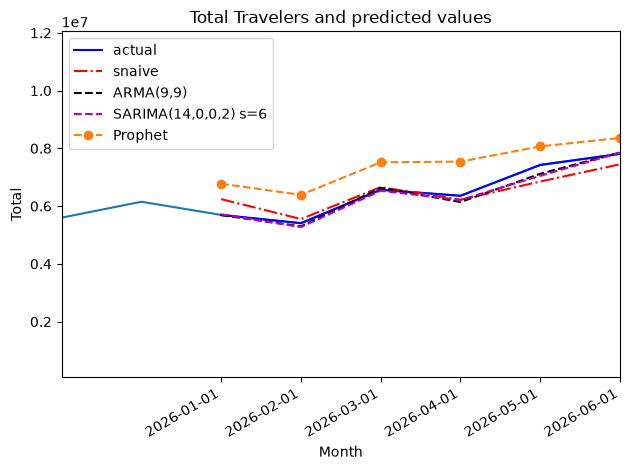

In [72]:
fig, ax = plt.subplots()
 
ax.plot(df['Total'])
ax.plot(pred_df['Total'], 'b-', label='actual')
# ax.plot(pred_df['pred_mean'], 'g:', label='mean')
ax.plot(pred_df['pred_snaive'], 'r-.', label='snaive')
# ax.plot(pred_df['pred_MA'], 'o:', label='MA')
# ax.plot(pred_df['pred_AR'], 'y-.', label='AR')
ax.plot(pred_df['pred_ARMA'], 'k--', label='ARMA(9,9)')
ax.plot(pred_df['pred_SARIMA'], 'm--', label='SARIMA(14,0,0,2) s=6')
ax.plot(df_pp_test['yhat'], 'o--', label='Prophet')
ax.legend(loc=2)
ax.set_xlabel('Month')
ax.set_ylabel('Total')
 
# ax.axvspan(6, 650, color='#808080', alpha=0.2)     
 
ax.set_xlim(646, 653)                                
 
plt.xticks(
    [648, 649, 650, 651, 652, 653],
    ['2026-01-01', '2026-02-01', '2026-03-01', '2026-04-01', '2026-05-01', "2026-06-01"])
 
fig.autofmt_xdate()

plt.title("Total Travelers and predicted values")
plt.tight_layout()

In [70]:

df_eval.loc[len(df_eval)] = [
"Prophet",
mape(df_pp_test['y'], df_pp_test['yhat']),
mean_squared_error(df_pp_test['y'], df_pp_test['yhat']),
mean_absolute_error(df_pp_test['y'], df_pp_test['yhat'])
]
df_eval

,Method,MAPE,MSE,MAE
0,mean,12.826919,8.060253e+11,801479.948642
1,snaive,4.697781,1.346010e+11,309225.000000
2,MA,11.476217,8.131889e+11,761242.794386
3,AR,8.796072,5.417258e+11,594198.520890
4,ARMA,1.885516,2.658377e+10,125614.108380
5,SARIMA,1.874217,3.068273e+10,125496.290254
6,Prophet,14.333774,8.599426e+11,899129.712667


# Conclusion

In [71]:
df_eval.sort_values(by="MAPE")

,Method,MAPE,MSE,MAE
5,SARIMA,1.874217,3.068273e+10,125496.290254
4,ARMA,1.885516,2.658377e+10,125614.108380
1,snaive,4.697781,1.346010e+11,309225.000000
3,AR,8.796072,5.417258e+11,594198.520890
2,MA,11.476217,8.131889e+11,761242.794386
0,mean,12.826919,8.060253e+11,801479.948642
6,Prophet,14.333774,8.599426e+11,899129.712667
